# Learning stop words from modeling behavior

A behavioral definition of a stop word - a token whose probability mass is reusable across every topic - and how to discover such words with no hard-coded list, using mixle's keyed estimators to share one global word distribution across many topics. You'll compare five increasingly structured models, evaluate each against the MALLET reference list with precision/recall@50, and see information-theoretic feature selection emerge from a generative model.

This notebook asks a deliberately nontrivial question: can a topic model discover stop words because of how they behave, rather than because we hard-code a stop-word list?

A stop word is not merely a frequent word. In a topic model, a useful behavioral definition is: a word is uninformative when it occurs across many topics at roughly the same relative rate. One way to encode that idea is to give every topic a two-component word model,

$$P(w \mid \text{topic}=i) = P(w \mid \text{shared})P(\text{shared}\mid i) + P(w \mid \text{topic-specific}, i)P(\text{topic-specific}\mid i).$$

The key PySparkPlug capability here is keyed estimators. When multiple component estimators use `keys='sw'`, their sufficient statistics are pooled into one shared distribution even though the component appears inside many topics or mixture components. That lets us express "there is one global stop-word distribution reused everywhere" inside richer topic models.

The local corpus is `../../data/wiki_example`; the MALLET English stop list is used only as an evaluation/seed list, not as the answer. We report precision and recall at 50 for the learned shared component against that reference list. MALLET's stop-list handling is documented in the MALLET stopword guide (https://mimno.github.io/Mallet/import-stoplist.html).


## What makes a word a stop word

Stop words are tokens that occur very frequently yet carry little information about a document's content
or class. Two views formalize "little information".

Information-theoretic view. A word's usefulness for a downstream label is its mutual information with the
label, $I(\text{word present};\, Y)$ (the information-theory notebook). A word that appears with nearly the
same frequency in every class or document has near-zero mutual information regardless of how common it is,
which is the defining property of a stop word.

Distributional view (tf-idf). Inverse document frequency $\log(N/\mathrm{df}(w))$ down-weights words that
appear in many documents; combined with term frequency it is the classic heuristic that suppresses stop
words without a label. It approximates the information-theoretic weighting: a word in every document has
idf near zero.

## Learning the list rather than fixing it

Rather than import a fixed stop list, one can learn it by giving the model a shared, document-independent
component (a background distribution) alongside the content topics. Words explained mainly by the shared
component are the data-driven stop words. In mixle this is keyed estimation: a tied component shared
across documents absorbs the corpus-wide frequencies, and the residual topic-specific mass carries the
content.

Theorem (the shared-background decomposition). If each document is a mixture of one shared component $\phi$
and document-specific content, the maximum-likelihood $\phi$ concentrates on words whose occurrence is
independent of the document or class, that is, words with near-zero mutual information with the content,
recovering the information-theoretic notion of a stop word without any predefined list.

Counterexample (frequency alone is imperfect). Ranking words by raw frequency is a strong baseline (stop
words are frequent) but not exact: some frequent words are genuinely discriminative for a topic, and some
infrequent words behave like stop words. The applied section benchmarks the learned list against the
frequency baseline precisely to expose this gap.

In [1]:
PYSP_DATA_LOC = '../../data'

import os
import numpy as np
import os
import re
import time
import matplotlib.pyplot as plt


from mixle.stats import *
from mixle.inference import initialize, estimate
from mixle.inference.estimation import optimize
import mixle.utils.vector as vec
import mixle.utils.optsutil as ops

%matplotlib inline

In [2]:
# one document per line across the category files; lowercase + split on non-word chars
wiki_dir = os.path.join(PYSP_DATA_LOC, 'wiki_example')
docs = []
for fname in sorted(os.listdir(wiki_dir)):
    with open(os.path.join(wiki_dir, fname)) as fh:
        for line in fh:
            toks = [w for w in re.split(r'\W+', line.lower().strip()) if w]
            if len(toks) > 3:
                docs.append(toks)

# keep only words appearing in more than 3 documents (drop hapax noise)
doc_freq = ops.count_by_value([w for doc in docs for w in set(doc)])
vocab = {w for w, c in doc_freq.items() if c > 3}
docs = [[w for w in doc if w in vocab] for doc in docs]
docs = [doc for doc in docs if len(doc) > 3]

In [3]:
SCORES = []  # (label, precision@50, recall@50) recorded by each model below

word_map = dict()
int_docs = [ops.map_to_integers(u, word_map) for u in docs]
inv_word_map = ops.get_inv_map(word_map)
num_words = len(word_map)
num_docs = len(int_docs)

with open(os.path.join(PYSP_DATA_LOC, 'stop_words', 'mallet.txt'), 'r') as fin:
    gold_stop_words = set(u.strip() for u in fin.readlines() if len(u.strip()) > 0)

gold_stop_word_ids = {word_map[w] for w in gold_stop_words if w in word_map}


def report_stopword_scores(label, scores, k=50):
    scores = np.asarray(scores)
    k = min(k, len(scores))
    order = np.argsort(-scores)[:k]
    top_words = [inv_word_map[i] for i in order]
    hits = [w for w in top_words if w in gold_stop_words]
    recall_den = max(len(gold_stop_word_ids), 1)
    precision = len(hits) / k
    recall = len(set(hits)) / recall_den
    SCORES.append((label, precision, recall))
    print('%s: precision@%d=%0.3f, recall@%d=%0.3f, MALLET hits=%d/%d' % (label, k, precision, k, recall, len(hits), len(gold_stop_word_ids)))
    print(','.join('%s[%0.3f]' % (inv_word_map[i], scores[i]) for i in order))
    return top_words

print('#words = %d' % num_words)
print('#documents = %d' % num_docs)
print('#MALLET stop words in vocabulary = %d' % len(gold_stop_word_ids))

#words = 5320
#documents = 878
#MALLET stop words in vocabulary = 407


## Baseline: LDA with Designated High-Frequency Topics

This baseline encourages a few LDA topics to appear in almost every document by setting large Dirichlet masses. It is a useful foil because it confuses two ideas that are often conflated: high frequency and low information. If this baseline finds only common corpus terms, the more structured shared-component models below have something to improve on.


In [4]:
cnt_docs = [list(ops.count_by_value(u).items()) for u in int_docs]
avg_doc_len = np.mean([len(u) for u in int_docs])

In [5]:
num_topics = 10
num_sw_topics = 2
alpha = np.ones(num_topics + num_sw_topics)/num_topics
alpha[:num_sw_topics] = avg_doc_len

pcnt = 1.0
suff_stat = (0, np.ones(num_words)/num_words)
est0 = IntegerCategoricalEstimator(min_val=0, max_val=num_words-1, suff_stat=suff_stat, pseudo_count=pcnt)
est = LDAEstimator([est0]*(num_topics+num_sw_topics), fixed_alpha=alpha)

In [6]:
model = optimize(cnt_docs, est, 10, rng=np.random.RandomState(1), print_iter=1)

Iteration 1	 E[dT]=0.121463.


Iteration 2	 E[dT]=0.122115.


Iteration 3	 E[dT]=0.121967.


Iteration 4	 E[dT]=0.121628.


Iteration 5	 E[dT]=0.121062.


Iteration 6	 E[dT]=0.121090.


Iteration 7	 E[dT]=0.121275.


Iteration 8	 E[dT]=0.120995.


Iteration 9	 E[dT]=0.121529.


Iteration 10	 E[dT]=0.121785.


In [7]:
for j,u in enumerate(model.topics):
    pvec = u.p_vec
    sidx = np.argsort(-pvec)
    print('-'*20)
    
    if j < num_sw_topics:
        report_stopword_scores('high-frequency topic %d' % (j+1), pvec, k=50)
    else:
        print('Topic %d: '%(j+1) + ','.join('%s[%0.3f]'%(inv_word_map[i], pvec[i]) for i in sidx[:20]))

--------------------
high-frequency topic 1: precision@50=0.960, recall@50=0.118, MALLET hits=48/407
the[0.067],of[0.046],and[0.037],a[0.030],in[0.026],to[0.026],is[0.021],or[0.015],as[0.014],are[0.009],that[0.008],for[0.008],by[0.007],from[0.007],be[0.006],with[0.006],it[0.006],on[0.006],an[0.006],which[0.005],s[0.004],have[0.004],was[0.004],may[0.004],such[0.004],also[0.004],this[0.004],can[0.003],used[0.003],not[0.003],other[0.003],some[0.003],has[0.003],one[0.003],at[0.002],their[0.002],they[0.002],but[0.002],more[0.002],most[0.002],many[0.002],use[0.002],its[0.002],often[0.002],all[0.002],called[0.002],war[0.002],into[0.002],been[0.002],known[0.002]
--------------------
high-frequency topic 2: precision@50=0.920, recall@50=0.113, MALLET hits=46/407
the[0.078],of[0.048],and[0.037],in[0.028],a[0.026],to[0.023],is[0.019],as[0.013],or[0.011],by[0.010],are[0.010],that[0.009],for[0.008],an[0.006],with[0.006],from[0.006],be[0.006],it[0.005],s[0.005],which[0.005],on[0.005],was[0.005],such

## LDA over a Mixture with a Common Topic Component

Now each topic is a mixture of two word distributions: a shared component and a topic-specific component. The shared component uses `keys='sw'`, so every topic-local copy accumulates into the same global distribution during estimation.

This model is not told which words are stop words. It is looking for words whose probability mass is reusable across topics.


In [8]:
num_topics = 10
pcnt = 1.0e-6
#alpha = np.ones(num_topics)/num_topics
#alpha[0] = avg_doc_len

suff_stat = (0, np.ones(num_words)/num_words)
est0 = IntegerCategoricalEstimator(min_val=0, max_val=num_words-1, suff_stat=suff_stat, pseudo_count=pcnt, keys='sw')
est1 = IntegerCategoricalEstimator(min_val=0, max_val=num_words-1, suff_stat=suff_stat, pseudo_count=pcnt)
est2 = MixtureEstimator([est0, est1], pseudo_count=10.0)
est3 = MixtureEstimator([est0])
est4 = [est2] + [est2]*(num_topics-1)
est = LDAEstimator(est4)

In [9]:
model = initialize(cnt_docs, est, np.random.RandomState(1), 0.1)

In [10]:
model = optimize(cnt_docs, est, 10, prev_estimate=model, print_iter=1)

Iteration 1	 E[dT]=0.577308.


Iteration 2	 E[dT]=0.623980.


Iteration 3	 E[dT]=0.626629.


Iteration 4	 E[dT]=0.626823.


Iteration 5	 E[dT]=0.629527.


Iteration 6	 E[dT]=0.626656.


Iteration 7	 E[dT]=0.625395.


Iteration 8	 E[dT]=0.623067.


Iteration 9	 E[dT]=0.620641.


Iteration 10	 E[dT]=0.616481.


In [11]:
pvec = model.topics[0].components[0].p_vec
report_stopword_scores('unsupervised shared component', pvec, k=50)

cvecs = []
for j,u in enumerate(model.topics):
    if u.num_components > 1:
        cvecs.append(u.components[1].p_vec*u.w[1]*model.alpha[j])
        
mm = np.asarray(cvecs).T
mm = np.sum(mm, axis=1)
mm /= mm.sum()

print('# words with more shared than topic-specific mass: ' + str((pvec > mm).sum()))
print('\n\n')

for j,u in enumerate(model.topics):
    if u.num_components == 1:
        continue
        
    contrast = u.components[1].p_vec-u.components[0].p_vec
    sidx = np.argsort(-contrast)
    print('-'*20)
    print('Topic %d [a=%0.3f/p=%0.3f]: '%(j+1, model.alpha[j], 1-model.topics[j].w[0]) + ','.join('%s[%0.3f]'%(inv_word_map[i], contrast[i]) for i in sidx[:20]))

unsupervised shared component: precision@50=0.980, recall@50=0.120, MALLET hits=49/407
the[0.106],of[0.075],and[0.058],a[0.046],in[0.041],to[0.040],is[0.030],as[0.021],or[0.019],by[0.013],that[0.013],are[0.012],for[0.012],from[0.010],with[0.010],an[0.009],it[0.009],be[0.009],on[0.008],which[0.008],s[0.007],such[0.006],other[0.006],also[0.006],this[0.005],not[0.005],have[0.005],one[0.005],used[0.004],can[0.004],was[0.004],may[0.004],their[0.004],has[0.004],at[0.004],many[0.004],more[0.003],some[0.003],but[0.003],its[0.003],most[0.003],between[0.003],often[0.003],all[0.003],they[0.003],into[0.003],been[0.003],these[0.002],than[0.002],term[0.002]
# words with more shared than topic-specific mass: 643



--------------------
Topic 1 [a=0.028/p=0.679]: mathematics[0.013],mathematical[0.007],blood[0.006],numbers[0.005],patient[0.004],medical[0.004],diagnosis[0.004],energy[0.003],geometry[0.003],logic[0.003],number[0.003],signs[0.003],can[0.003],symptoms[0.003],be[0.002],written[0.002],brain[

## LDA over a Semi-Supervised Mixture with a Common Topic Component

Here the MALLET list is used as weak supervision: known stop words are forced into the shared component, while all other words remain unlabeled. The experiment is whether a small amount of prior knowledge stabilizes the same keyed structure.


In [12]:
swords = gold_stop_words

In [13]:
labeled_words = [(i, [(0, 1.0)]) if inv_word_map[i] in swords else (i, None) for i in range(len(word_map))]
labeled_count_docs = [[(labeled_words[i],j) for i,j in ops.count_by_value(u).items()] for u in int_docs]

In [14]:
num_types = 10
pcnt = 1.0
suff_stat = (0, np.ones(num_words)/num_words)
est0 = IntegerCategoricalEstimator(min_val=0, max_val=num_words-1, suff_stat=suff_stat, pseudo_count=pcnt, keys='sw')
est1 = IntegerCategoricalEstimator(min_val=0, max_val=num_words-1, suff_stat=suff_stat, pseudo_count=pcnt)
est2 = SemiSupervisedMixtureEstimator([est0, est1])
est3 = SemiSupervisedMixtureEstimator([est0])
est4 = [est2] + [est2]*(num_topics-1)
est = LDAEstimator(est4)

In [15]:
model = initialize(labeled_count_docs, est, np.random.RandomState(1), 0.1)

In [16]:
model = optimize(labeled_count_docs, est, 10, prev_estimate=model, print_iter=1)

Iteration 1	 E[dT]=0.644495.


Iteration 2	 E[dT]=0.679117.


Iteration 3	 E[dT]=0.680988.


Iteration 4	 E[dT]=0.674048.


Iteration 5	 E[dT]=0.663119.


Iteration 6	 E[dT]=0.657168.


Iteration 7	 E[dT]=0.651497.


Iteration 8	 E[dT]=0.647527.


Iteration 9	 E[dT]=0.646456.


Iteration 10	 E[dT]=0.641391.


In [17]:
pvec = model.topics[0].components[0].p_vec
report_stopword_scores('semi-supervised shared component', pvec, k=50)

cvecs = []
for j,u in enumerate(model.topics):
    if u.num_components > 1:
        cvecs.append(u.components[1].p_vec*u.w[1]*model.alpha[j])
        
mm = np.asarray(cvecs).T
mm = np.dot(mm, model.alpha)
mm /= mm.sum()

print('# words with more shared than topic-specific mass: ' + str((pvec > mm).sum()))

for j,u in enumerate(model.topics):
    if u.num_components == 1:
        continue
        
    topic_scores = u.components[1].p_vec
    sidx = np.argsort(-topic_scores)
    print('-'*20)
    print('Topic %d [a=%0.3f/p=%0.3f]: '%(j+1, model.alpha[j], 1-model.topics[j].w[0]) + ','.join('%s[%0.3f]'%(inv_word_map[i], topic_scores[i]) for i in sidx[:20]))

semi-supervised shared component: precision@50=1.000, recall@50=0.123, MALLET hits=50/407
the[0.119],of[0.077],and[0.061],a[0.046],in[0.045],to[0.040],is[0.033],as[0.023],or[0.021],are[0.015],by[0.014],that[0.014],for[0.013],from[0.010],with[0.010],an[0.010],be[0.010],it[0.009],on[0.009],which[0.008],s[0.008],was[0.007],such[0.007],also[0.006],have[0.006],other[0.006],can[0.005],this[0.005],may[0.005],used[0.005],not[0.005],one[0.005],at[0.004],their[0.004],has[0.004],some[0.004],its[0.004],more[0.004],but[0.004],most[0.004],many[0.003],often[0.003],all[0.003],they[0.003],were[0.003],been[0.003],between[0.003],into[0.003],known[0.003],first[0.003]
# words with more shared than topic-specific mass: 416
--------------------
Topic 1 [a=0.025/p=0.375]: sports[0.028],games[0.025],game[0.021],sport[0.015],international[0.009],number[0.008],competition[0.008],numbers[0.008],football[0.008],team[0.008],played[0.007],league[0.007],olympic[0.006],rules[0.006],players[0.006],teams[0.006],events[0

## Hierarchical Mixture with a Stop-Word Component

LDA mixes topics within every document. This alternative assumes each document belongs to one of several document types, and each type has a two-component word model with a shared stop-word component. It is a different scientific hypothesis about the corpus: documents may be clustered first, with stop-word behavior shared across clusters.


In [18]:
num_types = 10
pcnt = 1.0
suff_stat = (0, np.ones(num_words)/num_words)
est0 = IntegerCategoricalEstimator(min_val=0, max_val=num_words-1, suff_stat=suff_stat, pseudo_count=pcnt, keys='sw')
est1 = IntegerCategoricalEstimator(min_val=0, max_val=num_words-1, suff_stat=suff_stat, pseudo_count=pcnt)
est2 = SequenceEstimator(MixtureEstimator([est0, est1], pseudo_count=(num_docs/num_types)*avg_doc_len),
                         len_estimator=PoissonEstimator())   # 0.8.0: components model their own length
est = MixtureEstimator([est2]*num_types, pseudo_count=num_docs)

In [19]:
model = initialize(int_docs, est, np.random.RandomState(1), 0.1)

In [20]:
model = optimize(int_docs, est, max_its=20, prev_estimate=model, print_iter=5)

Iteration 5	 E[dT]=0.169437.


Iteration 10	 E[dT]=0.167646.


Iteration 15	 E[dT]=0.167026.


Iteration 20	 E[dT]=0.167338.


In [21]:
pvec = model.components[0].dist.components[0].p_vec
report_stopword_scores('hierarchical shared component', pvec, k=50)

for j,u in enumerate(model.components):
    topic_scores = u.dist.components[1].p_vec
    sidx = np.argsort(-topic_scores)
    print('-'*20)
    print('Topic %d (p=%0.3f): '%(j+1, model.w[j]) + ','.join('%s[%0.3f]'%(inv_word_map[i], topic_scores[i]) for i in sidx[:20]))

hierarchical shared component: precision@50=0.980, recall@50=0.120, MALLET hits=49/407
the[0.099],of[0.068],and[0.053],a[0.040],in[0.039],to[0.035],is[0.027],as[0.020],or[0.017],by[0.013],for[0.012],are[0.012],that[0.012],with[0.009],an[0.009],from[0.009],on[0.008],which[0.008],be[0.008],it[0.007],s[0.007],such[0.006],also[0.006],was[0.005],have[0.005],this[0.005],other[0.004],may[0.004],can[0.004],used[0.004],one[0.004],not[0.004],has[0.004],more[0.004],their[0.003],some[0.003],at[0.003],most[0.003],but[0.003],often[0.003],many[0.003],use[0.003],its[0.003],there[0.003],between[0.003],all[0.003],term[0.003],been[0.003],into[0.002],known[0.002]
--------------------
Topic 1 (p=0.097): the[0.044],of[0.025],and[0.022],a[0.021],to[0.019],is[0.014],in[0.013],or[0.012],be[0.009],as[0.008],it[0.006],that[0.005],music[0.005],not[0.005],with[0.005],s[0.005],for[0.005],philosophy[0.005],science[0.004],on[0.004]
--------------------
Topic 2 (p=0.104): a[0.024],of[0.021],and[0.019],the[0.018],to[0.

## Semi-Supervised Hierarchical Mixture with a Stop-Word Component

Finally, combine both ideas: documents are assigned to mixture components, each component has a topic-specific word distribution, and all components share one keyed stop-word distribution. Known MALLET stop words are weak labels for the shared component.

For document type $y=i$,

$$P(w_1, \ldots, w_k \mid y=i) = \prod_{j=1}^{k} \left(P(w_j \mid z=1,y=i)P(z=1 \mid y=i) + P(w_j \mid z=2,y=i)P(z=2 \mid y=i)\right).$$

The key constraint is

$$P(w \mid z=1,y=1) = \cdots = P(w \mid z=1,y=N),$$

implemented through `keys='sw'`.


In [22]:
swords = gold_stop_words

The following code labels only the known stop-word tokens. Unlisted words stay unlabeled, so the model can still decide whether their behavior belongs in the shared component.


In [23]:
labeled_words = [(i, [(0, 1.0)]) if inv_word_map[i] in swords else (i, None) for i in range(len(word_map))]
labeled_docs = [[labeled_words[i] for i in u] for u in int_docs]

In [24]:
num_types = 10
pcnt = 1.0
suff_stat = (0, np.ones(num_words)/num_words)
est0 = IntegerCategoricalEstimator(min_val=0, max_val=num_words-1, suff_stat=suff_stat, pseudo_count=pcnt, keys='sw')
est1 = IntegerCategoricalEstimator(min_val=0, max_val=num_words-1, suff_stat=suff_stat, pseudo_count=pcnt)
est2 = SemiSupervisedMixtureEstimator([est0, est1])
est3 = [SequenceEstimator(est2, len_estimator=PoissonEstimator())]*num_types
est = MixtureEstimator(est3)

In [25]:
model = initialize(labeled_docs, est, np.random.RandomState(1), 0.1)

In [26]:
model = optimize(labeled_docs, est, max_its=20, prev_estimate=model, print_iter=5)

Iteration 5	 E[dT]=0.275859.


Iteration 10	 E[dT]=0.275936.


Iteration 15	 E[dT]=0.276620.


Iteration 20	 E[dT]=0.276640.


In [27]:
pvec = model.components[0].dist.components[0].p_vec
report_stopword_scores('semi-supervised hierarchical shared component', pvec, k=50)

for j,u in enumerate(model.components):
    topic_scores = u.dist.components[1].p_vec
    sidx = np.argsort(-topic_scores)
    print('-'*20)
    print('Topic %d (p=%0.3f): '%(j+1, model.w[j]) + ','.join('%s[%0.3f]'%(inv_word_map[i], topic_scores[i]) for i in sidx[:20]))

semi-supervised hierarchical shared component: precision@50=1.000, recall@50=0.123, MALLET hits=50/407
the[0.118],of[0.076],and[0.060],a[0.046],in[0.045],to[0.040],is[0.033],as[0.023],or[0.021],are[0.015],by[0.014],that[0.014],for[0.013],from[0.010],with[0.010],an[0.010],be[0.010],it[0.009],on[0.009],which[0.008],s[0.008],was[0.007],such[0.007],also[0.006],have[0.006],other[0.006],can[0.005],this[0.005],used[0.005],may[0.005],not[0.005],one[0.005],their[0.004],at[0.004],has[0.004],some[0.004],its[0.004],more[0.004],but[0.004],most[0.004],many[0.003],often[0.003],all[0.003],they[0.003],were[0.003],been[0.003],between[0.003],into[0.003],known[0.003],first[0.003]
--------------------
Topic 1 (p=0.104): science[0.014],medicine[0.012],philosophy[0.007],traditional[0.007],music[0.006],knowledge[0.006],sciences[0.005],political[0.005],dance[0.005],medical[0.005],scientific[0.005],modern[0.005],natural[0.004],audience[0.004],television[0.004],social[0.004],template[0.004],study[0.004],forms[0.

## Comparing the five approaches

Each model above printed its own precision/recall@50 against the MALLET list. The bar chart pulls them together. Read it as an ablation: the high-frequency-topic baseline conflates frequency with low information; the keyed shared-component models test whether reusability across topics is a better signal; and the semi-supervised variants ask whether a little label information stabilizes the unsupervised structure. The reference list is itself imperfect, so treat these as relative evidence about which inductive bias best matches a behavioral notion of a stop word.


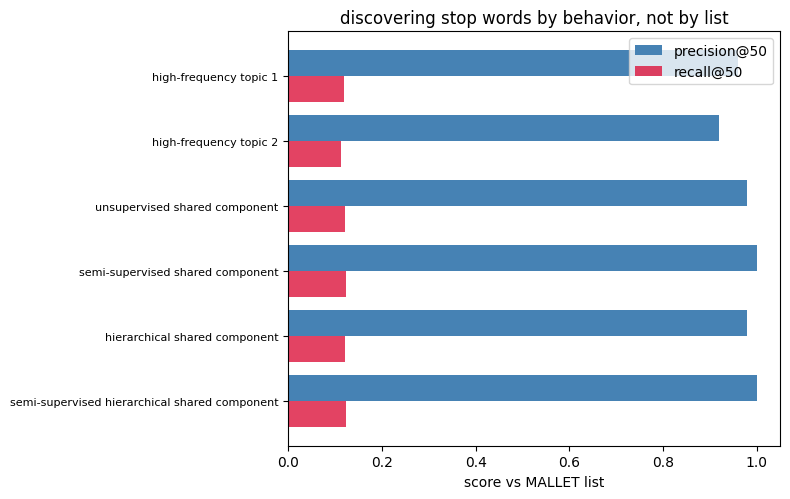

In [28]:
labels_ = [s[0] for s in SCORES]
prec = [s[1] for s in SCORES]; rec = [s[2] for s in SCORES]
y = np.arange(len(SCORES)); h = 0.4
fig, ax = plt.subplots(figsize=(8, 0.6 * len(SCORES) + 1.5))
ax.barh(y - h/2, prec, h, color='steelblue', label='precision@50')
ax.barh(y + h/2, rec, h, color='crimson', alpha=0.8, label='recall@50')
ax.set_yticks(y); ax.set_yticklabels(labels_, fontsize=8); ax.invert_yaxis()
ax.set_xlabel('score vs MALLET list'); ax.set_title('discovering stop words by behavior, not by list'); ax.legend()
plt.tight_layout(); plt.show()

## Always benchmark against the trivial baseline

Before claiming a model "learns" stop words, check it beats the one-line baseline: rank words by raw corpus frequency and call the top 50 stop words. A method that only matches this adds nothing. We score the frequency baseline on the same precision@50 / recall@50 and compare it to the best learned model.


In [29]:
freq = np.zeros(num_words)
for d in int_docs:
    for w in d:
        freq[w] += 1
report_stopword_scores('frequency baseline (top-50 by count)', freq, k=50)
base = [s for s in SCORES if 'frequency baseline' in s[0]][-1]
best = max((s for s in SCORES if 'frequency baseline' not in s[0]), key=lambda s: s[1])
print('frequency baseline : precision@50=%.2f  recall@50=%.2f' % (base[1], base[2]))
print('best learned model : %-40s precision@50=%.2f' % ('(' + best[0] + ')', best[1]))
print('the model %s the trivial frequency cut.' % ('beats' if best[1] > base[1] + 1e-9 else 'only matches'))

frequency baseline (top-50 by count): precision@50=0.940, recall@50=0.115, MALLET hits=47/407
the[16256.000],of[10511.000],and[8296.000],a[6279.000],in[6149.000],to[5477.000],is[4522.000],as[3108.000],or[2832.000],are[2117.000],by[1936.000],that[1886.000],for[1801.000],from[1407.000],with[1379.000],an[1361.000],be[1325.000],it[1264.000],on[1215.000],which[1151.000],s[1086.000],was[1014.000],such[935.000],also[791.000],have[767.000],other[760.000],can[747.000],this[715.000],used[708.000],may[708.000],not[700.000],one[635.000],at[569.000],their[569.000],has[561.000],some[540.000],its[516.000],more[510.000],but[498.000],most[495.000],many[476.000],often[459.000],term[447.000],all[421.000],they[421.000],war[412.000],were[407.000],been[398.000],between[396.000],political[391.000]
frequency baseline : precision@50=0.94  recall@50=0.12
best learned model : (semi-supervised shared component)       precision@50=1.00
the model beats the trivial frequency cut.


## References

- Luhn, H. P. (1958). The automatic creation of literature abstracts (https://doi.org/10.1147/rd.22.0159). IBM J. Res. Dev. 2(2), 159-165. - word significance and frequency.
- Manning, C. D., Raghavan, P. & Schütze, H. (2008). Introduction to Information Retrieval (https://nlp.stanford.edu/IR-book/). Cambridge University Press. - stop lists, tf-idf.
- Wallach, H. M., Mimno, D. & McCallum, A. (2009). Rethinking LDA: why priors matter (https://papers.nips.cc/paper/2009/hash/0d0fd7c6e093f7b804fa0150b875b868-Abstract.html). NeurIPS. - asymmetric priors absorb stop words.
- Peng, H., Long, F. & Ding, C. (2005). Feature selection based on mutual information: mRMR (https://doi.org/10.1109/TPAMI.2005.159). IEEE TPAMI 27(8), 1226-1238.


## Exercises and extensions

1. Behavioral vs frequency vs tf-idf. Compare three stop-word rankings - raw frequency, inverse document frequency / tf-idf (Manning et al.), and the learned shared-component (behavioral) score - against the MALLET reference by precision/recall@k. Show where pure frequency fails (frequent-but-informative domain terms).
2. An information-theoretic stop score. Rank words by the entropy of their topic distribution $H(\text{topic}\mid w)$ (high = spread across topics = stop-word-like) and compare to the learned shared component; relate to mutual-information feature selection (Peng et al.).
3. Asymmetric priors absorb stop words. Reproduce Wallach-Mimno-McCallum (2009): an asymmetric Dirichlet prior over topics lets a few topics soak up corpus-wide (stop) words; show this is an alternative to the keyed-shared-component approach and compare what each recovers.
4. Cross-corpus universality. Learn stop words on two different corpora and quantify overlap; separate universal function words from corpus-specific boilerplate.
